In [2]:
# Import the main libraries needed for data cleaning, analysis, visualization, statistics, and machine learning.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [3]:
# Uploading the California weather and wildfire dataset into a pandas DataFrame.

df = pd.read_csv("CA_Weather_Fire_Dataset_1984-2025.csv")


df.head()  # I use df.head() to quickly preview the first few rows and make sure the file loaded correctly.

,DATE,PRECIPITATION,MAX_TEMP,MIN_TEMP,AVG_WIND_SPEED,FIRE_START_DAY,YEAR,TEMP_RANGE,WIND_TEMP_RATIO,MONTH,SEASON,LAGGED_PRECIPITATION,LAGGED_AVG_WIND_SPEED,DAY_OF_YEAR
0,1/1/1984,0.0,79.0,51.0,4.70,False,1984,28.0,0.059494,1,Winter,0.0,4.700,1
1,1/2/1984,0.0,71.0,46.0,5.59,False,1984,25.0,0.078732,1,Winter,0.0,5.145,2
2,1/3/1984,0.0,70.0,47.0,5.37,False,1984,23.0,0.076714,1,Winter,0.0,5.220,3
3,1/4/1984,0.0,76.0,45.0,4.70,False,1984,31.0,0.061842,1,Winter,0.0,5.090,4
4,1/5/1984,0.0,74.0,49.0,5.14,False,1984,25.0,0.069459,1,Winter,0.0,5.100,5


In [4]:
# Check the size of the dataset, column types, and summary statistics.
# This helps me understand what variables I have and whether anything looks unusual before cleaning.
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (14988, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14988 entries, 0 to 14987
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   DATE                   14988 non-null  object 
 1   PRECIPITATION          14987 non-null  float64
 2   MAX_TEMP               14987 non-null  float64
 3   MIN_TEMP               14987 non-null  float64
 4   AVG_WIND_SPEED         14976 non-null  float64
 5   FIRE_START_DAY         14988 non-null  bool   
 6   YEAR                   14988 non-null  int64  
 7   TEMP_RANGE             14987 non-null  float64
 8   WIND_TEMP_RATIO        14976 non-null  float64
 9   MONTH                  14988 non-null  int64  
 10  SEASON                 14988 non-null  object 
 11  LAGGED_PRECIPITATION   14988 non-null  float64
 12  LAGGED_AVG_WIND_SPEED  14988 non-null  float64
 13  DAY_OF_YEAR            14988 non-null  int64  
dtypes: bool(1), float64(8), int64(3), o

,PRECIPITATION,MAX_TEMP,MIN_TEMP,AVG_WIND_SPEED,YEAR,TEMP_RANGE,WIND_TEMP_RATIO,MONTH,LAGGED_PRECIPITATION,LAGGED_AVG_WIND_SPEED,DAY_OF_YEAR
count,14987.000000,14987.000000,14987.000000,14976.000000,14988.000000,14987.000000,14976.000000,14988.000000,14988.000000,14988.000000,14988.000000
mean,0.032315,70.534997,56.494095,7.435098,2004.016813,14.040902,0.107019,6.518281,0.226188,7.434198,182.992994
std,0.179544,7.263447,6.767685,2.129985,11.843342,5.995327,0.035630,3.451037,0.648705,1.387849,105.523627
min,0.000000,50.000000,33.000000,1.790000,1984.000000,2.000000,0.023553,1.000000,0.000000,3.227143,1.000000
25%,0.000000,65.000000,51.000000,6.040000,1994.000000,10.000000,0.085238,4.000000,0.000000,6.518571,92.000000
50%,0.000000,70.000000,57.000000,7.160000,2004.000000,12.000000,0.102222,7.000000,0.000000,7.478571,183.000000
75%,0.000000,75.000000,62.000000,8.500000,2014.000000,17.000000,0.120462,10.000000,0.060000,8.278571,274.000000
max,4.530000,106.000000,77.000000,26.170000,2025.000000,41.000000,0.459123,12.000000,8.180000,13.932857,366.000000


In [5]:
# Convert the DATE column into a datetime format so Python recognizes it as a real date.
df['DATE'] = pd.to_datetime(df['DATE'])

# Convert FIRE_START_DAY from True/False into 1/0 so it can be used in machine learning models.
df['FIRE_START_DAY'] = df['FIRE_START_DAY'].astype(int)

# check for missing values to see what needs to be cleaned.
print(df.isnull().sum())

DATE                      0
PRECIPITATION             1
MAX_TEMP                  1
MIN_TEMP                  1
AVG_WIND_SPEED           12
FIRE_START_DAY            0
YEAR                      0
TEMP_RANGE                1
WIND_TEMP_RATIO          12
MONTH                     0
SEASON                    0
LAGGED_PRECIPITATION      0
LAGGED_AVG_WIND_SPEED     0
DAY_OF_YEAR               0
dtype: int64


In [6]:
# Since only a small number of values are missing, I fill them using the column mean. This keeps the rows in the dataset instead of dropping useful data.

for col in ['PRECIPITATION', 'MAX_TEMP', 'MIN_TEMP', 'TEMP_RANGE', 'AVG_WIND_SPEED', 'WIND_TEMP_RATIO']:
    df[col].fillna(df[col].mean(), inplace=True)

print(df.isnull().sum())   # After filling, I check missing values again to confirm the issue is fixed.

DATE                     0
PRECIPITATION            0
MAX_TEMP                 0
MIN_TEMP                 0
AVG_WIND_SPEED           0
FIRE_START_DAY           0
YEAR                     0
TEMP_RANGE               0
WIND_TEMP_RATIO          0
MONTH                    0
SEASON                   0
LAGGED_PRECIPITATION     0
LAGGED_AVG_WIND_SPEED    0
DAY_OF_YEAR              0
dtype: int64


C:\Users\onemo\AppData\Local\Temp\ipykernel_15040\3715371689.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


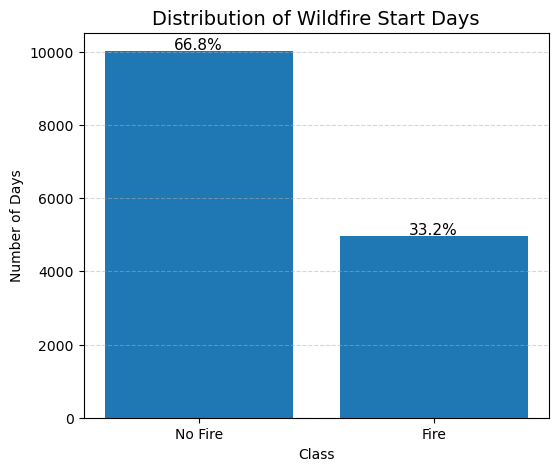

In [7]:
# Visualize how many days are fire-start days compared to non-fire days.

counts = df['FIRE_START_DAY'].value_counts()
labels = ['No Fire', 'Fire']

plt.figure(figsize=(6,5))
bars = plt.bar(labels, counts.values)

# Add percentages on top
total = counts.sum()
for i, v in enumerate(counts.values):
    pct = v / total * 100
    plt.text(i, v + 50, f"{pct:.1f}%", ha='center', fontsize=11)      # Adding percentages makes it easier to see the class balance in the dataset.

plt.title("Distribution of Wildfire Start Days", fontsize=14)
plt.ylabel("Number of Days")
plt.xlabel("Class")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


In [8]:
# Split the dataset into fire days and non-fire days.
# Then compare the average temperature, precipitation, and wind speed between the two groups.
# This helps identify which weather conditions appear different on fire-start days.

fire_days = df[df['FIRE_START_DAY'] == 1]
no_fire_days = df[df['FIRE_START_DAY'] == 0]

print("Average Max Temp (Fire Days):", np.mean(fire_days['MAX_TEMP']))
print("Average Max Temp (No Fire):", np.mean(no_fire_days['MAX_TEMP']))

print("Average Precipitation (Fire Days):", np.mean(fire_days['PRECIPITATION']))
print("Average Precipitation (No Fire):", np.mean(no_fire_days['PRECIPITATION']))

print("Average Wind Speed (Fire Days):", np.mean(fire_days['AVG_WIND_SPEED']))
print("Average Wind Speed (No Fire):", np.mean(no_fire_days['AVG_WIND_SPEED']))

# Wildfire start days are associated with higher average temperatures and significantly lower precipitation levels compared to non-fire days.
# Wind speed shows only a minor difference between the two groups, suggesting it may be a less influential factor.”



Average Max Temp (Fire Days): 74.33232749949708
Average Max Temp (No Fire): 68.65054756883272
Average Precipitation (Fire Days): 0.0028525447596057132
Average Precipitation (No Fire): 0.046935441217202396
Average Wind Speed (Fire Days): 7.529422651377991
Average Wind Speed (No Fire): 7.388289026443507


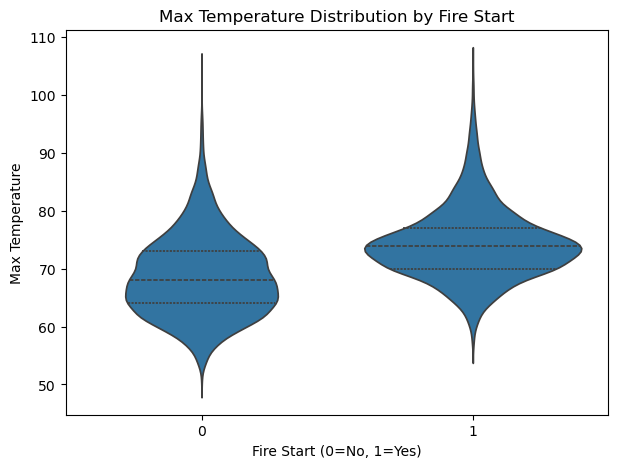

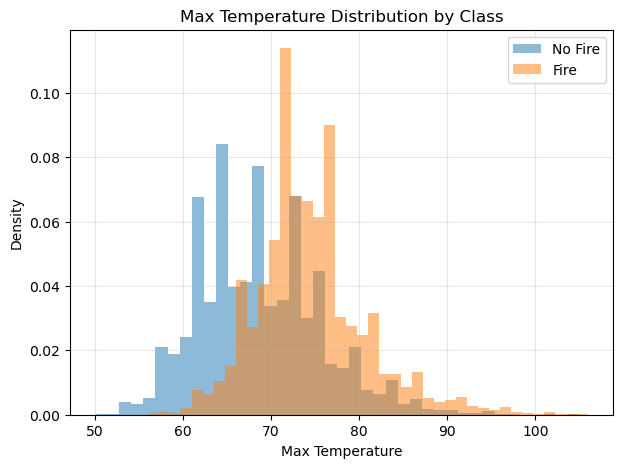

In [18]:
import seaborn as sns
# Use a violin plot to compare the distribution of max temperature for fire and non-fire days.
# This gives more detail than a simple bar chart because it shows the shape of the data.

plt.figure(figsize=(7,5))
sns.violinplot(x='FIRE_START_DAY', y='MAX_TEMP', data=df, inner='quartile')
plt.title("Max Temperature Distribution by Fire Start")
plt.xlabel("Fire Start (0=No, 1=Yes)")
plt.ylabel("Max Temperature")
plt.show()

# Use overlapping histograms to compare temperature distributions between fire and non-fire days.
# This helps show whether fire days are generally shifted toward higher temperatures.
plt.figure(figsize=(7,5))
plt.hist(df[df['FIRE_START_DAY']==0]['MAX_TEMP'], bins=40, alpha=0.5, density=True, label='No Fire')
plt.hist(df[df['FIRE_START_DAY']==1]['MAX_TEMP'], bins=40, alpha=0.5, density=True, label='Fire')

plt.title("Max Temperature Distribution by Class")
plt.xlabel("Max Temperature")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#“Visualization of maximum temperature using violin and histogram plots shows a clear shift toward higher values on wildfire start days, suggesting temperature is a strong contributing factor.
# Precipitation distributions indicate that wildfire events occur primarily on days with little to no rainfall, reinforcing the role of dry conditions in wildfire ignition.”



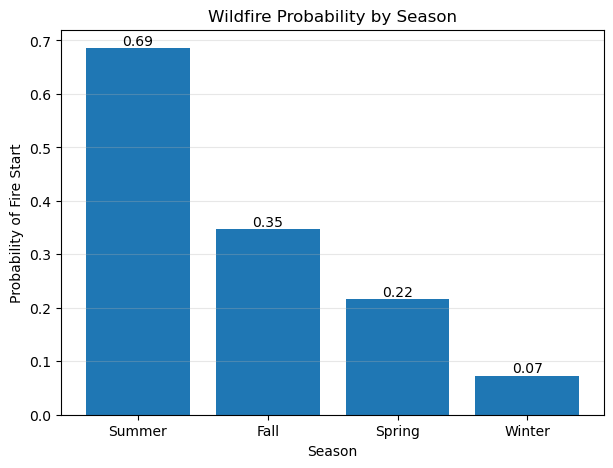

In [10]:
# Calculate the wildfire rate for each season by taking the average of FIRE_START_DAY.
# Since FIRE_START_DAY is 0 or 1, the mean represents the proportion of days with a fire start.
# This is better than only counting fires because it compares seasons by the probability.

plt.figure(figsize=(7,5))

season_rate = df.groupby('SEASON')['FIRE_START_DAY'].mean()
season_rate = season_rate.sort_values(ascending=False)

plt.bar(season_rate.index, season_rate.values)

for i, v in enumerate(season_rate.values):
    plt.text(i, v + 0.005, f"{v:.2f}", ha='center')

plt.title("Wildfire Probability by Season")
plt.ylabel("Probability of Fire Start")
plt.xlabel("Season")
plt.grid(axis='y', alpha=0.3)

plt.show()

In [11]:
# T-test: Max Temp
t_stat, p_val = stats.ttest_ind(
    fire_days['MAX_TEMP'],
    no_fire_days['MAX_TEMP'],
    equal_var=False  # I use equal_var=False because the two groups may not have the same variance
)
# The goal is to test whether temperature and precipitation are significantly different between the two groups.

print("T-test MAX_TEMP p-value:", p_val)

# T-test: Precipitation
t_stat, p_val = stats.ttest_ind(
    fire_days['PRECIPITATION'],
    no_fire_days['PRECIPITATION'],
    equal_var=False
)

print("T-test PRECIPITATION p-value:", p_val)

print("Mean Temp Difference:", fire_days['MAX_TEMP'].mean() - no_fire_days['MAX_TEMP'].mean())
print("Mean Precip Difference:", fire_days['PRECIPITATION'].mean() - no_fire_days['PRECIPITATION'].mean())

#“Statistical testing using Welch’s t-test indicates that both maximum temperature and precipitation statistically differ significantly between wildfire and non-wildfire days (p < 0.001).
#This confirms that higher temperatures and lower precipitation are strongly associated with wildfire occurrence.”

T-test MAX_TEMP p-value: 0.0
T-test PRECIPITATION p-value: 7.854002917435431e-83
Mean Temp Difference: 5.681779930664362
Mean Precip Difference: -0.044082896457596686


In [12]:
# Drop DATE and YEAR before modeling.
# DATE is not directly useful for the model, and YEAR could cause the model to learn long-term trends instead of weather patterns.
# Convert SEASON into dummy variables so the model can use it as numeric input.
# Then separate the features X from the target variable y.

df = df.drop(columns=['DATE', 'YEAR'])
df = pd.get_dummies(df, columns=['SEASON'], drop_first=True)
X = df.drop(columns=['FIRE_START_DAY'])
y = df['FIRE_START_DAY']

# Split the data into training and testing sets.
# The model learns from the training data and is evaluated on the test data.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
# Scale the features before using Logistic Regression because this model is affected by feature size.
# StandardScaler puts the variables on a similar scale.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression as a baseline model.
# This gives a simple and interpretable model to compare against Random Forest.

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

# Evaluate the Logistic Regression model using accuracy, precision, recall, and F1-score.
# These metrics are important because accuracy alone does not fully explain performance on fire prediction.

print("Logistic Regression:")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

Logistic Regression:
Accuracy: 0.7685123415610406
Precision: 0.6748466257668712
Recall: 0.5617977528089888
F1 Score: 0.6131549609810479

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.87      0.83      2019
           1       0.67      0.56      0.61       979

    accuracy                           0.77      2998
   macro avg       0.74      0.72      0.72      2998
weighted avg       0.76      0.77      0.76      2998



In [15]:
# Train an initial Random Forest model using 100 trees.
# Random Forest can capture more complex and nonlinear relationships than Logistic Regression.

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

# Evaluate the initial Random Forest model using the same metrics as Logistic Regression
# so both models can be compared.

print("Random Forest:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest:
Accuracy: 0.7601734489659773
Precision: 0.6511627906976745
Recall: 0.5720122574055159
F1 Score: 0.609026644915715

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.85      0.83      2019
           1       0.65      0.57      0.61       979

    accuracy                           0.76      2998
   macro avg       0.73      0.71      0.72      2998
weighted avg       0.75      0.76      0.76      2998



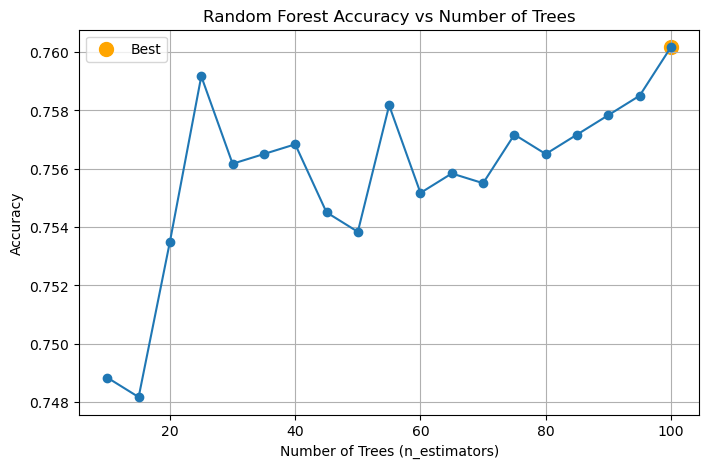

In [16]:
# Test different numbers of trees in the Random Forest model.
# This helps me see how model accuracy changes as n_estimators increases.
# Also, this is my honors project for B211 class.
accuracies = []
n_values = list(range(10, 101, 5))

for n in n_values:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    accuracies.append(acc)

# Pick the number of trees that gives the highest accuracy.
best_n = n_values[np.argmax(accuracies)]
best_acc = max(accuracies)

# Plot accuracy against the number of trees to visualize the hyperparameter experiment.
plt.figure(figsize=(8,5))
plt.plot(n_values, accuracies, marker='o')

plt.scatter(best_n, best_acc, color='orange', s=100, label='Best')

plt.title("Random Forest Accuracy vs Number of Trees")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.show()

In [17]:
# Pciking the best model

print("Best n_estimators:", best_n)
print("Best accuracy:", best_acc)

Best n_estimators: 100
Best accuracy: 0.7601734489659773


In [18]:
# Train the final Random Forest model using the best number of trees found in the experiment.
# This becomes the optimized Random Forest model used for final comparison.

rf_best = RandomForestClassifier(n_estimators=best_n, random_state=42)
rf_best.fit(X_train, y_train)

y_pred_best = rf_best.predict(X_test)

# Evaluate the best Random Forest model using accuracy, precision, recall, and F1-score.
print("Best Random Forest:")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1 Score:", f1_score(y_test, y_pred_best))

Best Random Forest:
Accuracy: 0.7601734489659773
Precision: 0.6511627906976745
Recall: 0.5720122574055159
F1 Score: 0.609026644915715


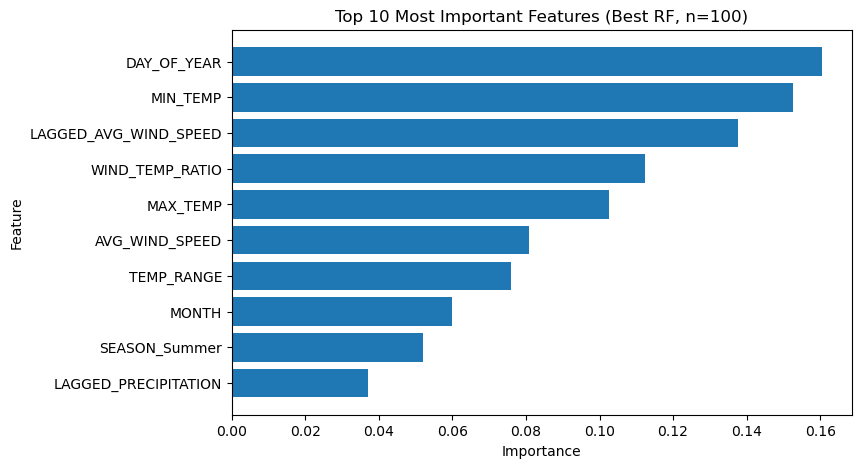

In [19]:
# Use the best Random Forest model to find which features were most important for prediction.
# Feature importance helps explain which variables the model relied on the most.

importances = rf_best.feature_importances_
features = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(10)

# Plot the top 10 most important features.
top_features = feature_importance_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()

plt.title(f"Top 10 Most Important Features (Best RF, n={best_n})")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [20]:
# Create a comparison table for Logistic Regression and the best Random Forest model.
# This makes it easier to compare the models side by side using the same evaluation metrics.

results = pd.DataFrame({
    'Model': ['Logistic Regression', f'Best Random Forest (n={best_n})'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_best)
    ],
    'Precision': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_best)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_best)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_best)
    ]
})

results.round(3)

# Confusion matrix analysis reveals a trade-off between the two models. While Random Forest slightly improves recall 
# by detecting more wildfire events, it does so at the cost of increased false positives. 
#Logistic Regression, on the other hand, produces fewer false alarms but misses slightly more wildfire events.”

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.769,0.675,0.562,0.613
1,Best Random Forest (n=100),0.760,0.651,0.572,0.609


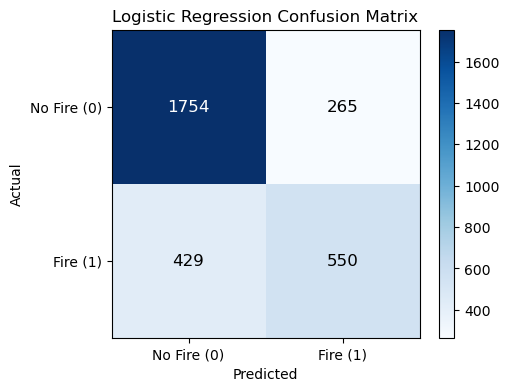

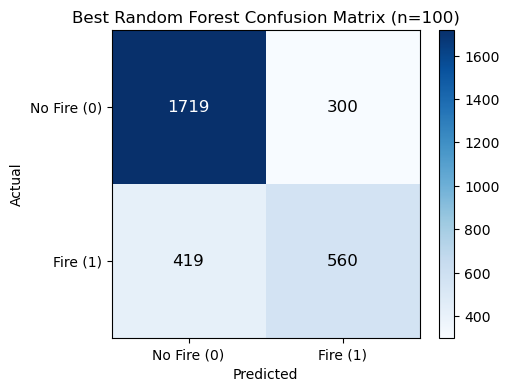

In [21]:
# Define a function to plot confusion matrices for any model.
# The confusion matrix shows correct predictions and mistakes for both fire and non-fire days.

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    plt.imshow(cm, cmap='Blues')
    plt.title(title)
    plt.colorbar()

    labels = ['No Fire (0)', 'Fire (1)']
    plt.xticks([0,1], labels)
    plt.yticks([0,1], labels)

    # Use a threshold so the text color changes depending on the background color.
    # This makes the numbers easier to read in darker cells.
    
    threshold = cm.max() / 2    #having dynamic text color

    for i in range(2):
        for j in range(2):
            color = "white" if cm[i, j] > threshold else "black"
            plt.text(j, i, cm[i, j], ha='center', va='center', color=color, fontsize=12)
            
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Plot confusion matrices for Logistic Regression and the best Random Forest model.
plot_confusion(y_test, y_pred_log, "Logistic Regression Confusion Matrix")
plot_confusion(y_test, y_pred_best, f"Best Random Forest Confusion Matrix (n={best_n})")